<a href="https://colab.research.google.com/github/ruchira0011/Electricity-Demand-Forecasting-in-Great-Britain/blob/main/Uk_Energy_Sarimax.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing Data

In [17]:
import pandas as pd

# List of NESO Historic Demand CSV URLs (you can extend this list)
urls = {
    2026: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/8a4a771c-3929-4e56-93ad-cdf13219dea5/download/demanddata_2026.csv",
    2025: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/b2bde559-3455-4021-b179-dfe60c0337b0/download/demanddata_2025.csv",
    2024: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/f6d02c0f-957b-48cb-82ee-09003f2ba759/download/demanddata_2024.csv",
    2023: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/bf5ab335-9b40-4ea4-b93a-ab4af7bce003/download/demanddata_2023.csv",
    2022: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/bb44a1b5-75b1-4db2-8491-257f23385006/download/demanddata_2022.csv",
    2021: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/18c69c42-f20d-46f0-84e9-e279045befc6/download/demanddata_2021.csv",
    2020: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/33ba6857-2a55-479f-9308-e5c4c53d4381/download/demanddata_2020.csv",
    2019: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/dd9de980-d724-415a-b344-d8ae11321432/download/demanddata_2019.csv",
    2018: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/fcb12133-0db0-4f27-a4a5-1669fd9f6d33/download/demanddata_2018.csv",
    2017: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/2f0f75b8-39c5-46ff-a914-ae38088ed022/download/demanddata_2017.csv",
    2016: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/3bb75a28-ab44-4a0b-9b1c-9be9715d3c44/download/demanddata_2016.csv",
    2015: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/cc505e45-65ae-4819-9b90-1fbb06880293/download/demanddata_2015.csv",
    2014: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/b9005225-49d3-40d1-921c-03ee2d83a2ff/download/demanddata_2014.csv",
    2013: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/2ff7aaff-8b42-4c1b-b234-9446573a1e27/download/demanddata_2013.csv",
    2012: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/4bf713a2-ea0c-44d3-a09a-63fc6a634b00/download/demanddata_2012.csv",
    2011: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/01522076-2691-4140-bfb8-c62284752efd/download/demanddata_2011.csv",
    2010: "https://api.neso.energy/dataset/8f2fe0af-871c-488d-8bad-960426f24601/resource/b3eae4a5-8c3c-4df1-b9de-7db243ac3a09/download/demanddata_2010.csv"
}

def load_neso_demand(urls: dict) -> pd.DataFrame:
    dfs = []
    for year, url in urls.items():
        print(f"Loading {year} data...")
        df_year = pd.read_csv(url)
        df_year["Year"] = year  # optional: keep track of source year
        dfs.append(df_year)
    return pd.concat(dfs, ignore_index=True)

df = load_neso_demand(urls)

print("Shape:", df.shape)
print(df.head())
print(df.columns)

Loading 2026 data...
Loading 2025 data...
Loading 2024 data...
Loading 2023 data...
Loading 2022 data...
Loading 2021 data...
Loading 2020 data...
Loading 2019 data...
Loading 2018 data...
Loading 2017 data...
Loading 2016 data...
Loading 2015 data...
Loading 2014 data...
Loading 2013 data...
Loading 2012 data...
Loading 2011 data...
Loading 2010 data...
Shape: (284782, 23)
  SETTLEMENT_DATE  SETTLEMENT_PERIOD     ND    TSD  ENGLAND_WALES_DEMAND  \
0      2026-01-01                  1  25107  29668                 23625   
1      2026-01-01                  2  25881  30361                 24341   
2      2026-01-01                  3  25355  30681                 23805   
3      2026-01-01                  4  24762  30225                 23226   
4      2026-01-01                  5  24111  29092                 22653   

   EMBEDDED_WIND_GENERATION  EMBEDDED_WIND_CAPACITY  \
0                      4252                    6606   
1                      4332                    6606   
2

In [2]:
df.tail()

,SETTLEMENT_DATE,SETTLEMENT_PERIOD,ND,TSD,ENGLAND_WALES_DEMAND,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,EMBEDDED_SOLAR_GENERATION,EMBEDDED_SOLAR_CAPACITY,NON_BM_STOR,...,IFA2_FLOW,BRITNED_FLOW,MOYLE_FLOW,EAST_WEST_FLOW,NEMO_FLOW,NSL_FLOW,ELECLINK_FLOW,VIKING_FLOW,GREENLINK_FLOW,Year
284777,31-DEC-2010,44,35215,36272,31765,390,2141,0,79,0,...,0,0,-450,0,0,NaN,NaN,NaN,NaN,2010
284778,31-DEC-2010,45,34181,35238,30811,390,2141,0,79,0,...,0,0,-450,0,0,NaN,NaN,NaN,NaN,2010
284779,31-DEC-2010,46,33822,34871,30399,449,2141,0,79,0,...,0,0,-442,0,0,NaN,NaN,NaN,NaN,2010
284780,31-DEC-2010,47,33410,34403,29831,449,2141,0,79,0,...,0,0,-381,0,0,NaN,NaN,NaN,NaN,2010
284781,31-DEC-2010,48,33457,34516,29843,484,2141,0,79,0,...,0,0,-382,0,0,NaN,NaN,NaN,NaN,2010


# Data Preprocessing

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df.drop(columns=['SCOTTISH_TRANSFER','NSL_FLOW','ELECLINK_FLOW','VIKING_FLOW',
                 'GREENLINK_FLOW', 'IFA_FLOW', 'IFA2_FLOW', 'BRITNED_FLOW',
                 'MOYLE_FLOW', 'EAST_WEST_FLOW', 'NEMO_FLOW'], inplace=True)

# 1. Convert date column to datetime
df["SETTLEMENT_DATE"] = pd.to_datetime(df["SETTLEMENT_DATE"], format='mixed',
                                       dayfirst=True)

# 2. Ensure settlement period is numeric
df["SETTLEMENT_PERIOD"] = pd.to_numeric(df["SETTLEMENT_PERIOD"])

# 3. Create full timestamp (each period = 30 minutes)
df["timestamp"] = df["SETTLEMENT_DATE"] + pd.to_timedelta(
    (df["SETTLEMENT_PERIOD"] - 1) * 30, unit="min"
)

# 4. Set timestamp as index
df = df.set_index("timestamp")

# 5. Sort by time
df = df.sort_index()

# 6. Assign demand column
demand_col = "ND"
demand = df[demand_col]

# 7. Basic dataset info
print("Data shape:", df.shape)
print("Date range:", df.index.min(), "to", df.index.max())

# 8. Demand statistics
print(demand.describe())


# missing value handling
# Missingness
missing = df.isna().mean().sort_values(ascending=False) * 100
print("Top missing % columns:")
display(missing.head(10))

# Duplicates in time index
dup_count = df.index.duplicated().sum()
print("Duplicate timestamps:", dup_count)

# If duplicates exist, aggregate them
if dup_count > 0:
    df = df.groupby(df.index).mean(numeric_only=True)
    print("After aggregating duplicates -> shape:", df.shape)


Data shape: (284782, 23)
Date range: 2010-01-01 00:00:00 to 2026-03-30 23:30:00
count    284782.000000
mean      30569.080419
std        7696.802738
min       12803.000000
25%       24410.000000
50%       29769.500000
75%       36140.000000
max       59095.000000
Name: ND, dtype: float64


# Sarimax Model

Final shape: (47464,)
Date range: 2010-01-01 00:00:00 to 2026-03-30 21:00:00


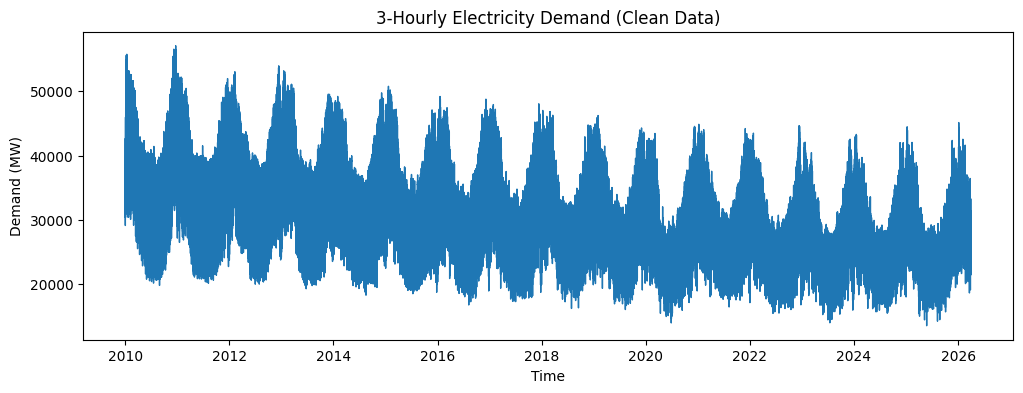

In [19]:
# -------------------------------
# 6. RESAMPLE → 4-HOURLY
# -------------------------------
series = df["ND"].resample("3h").mean().dropna()

# Remove missing after resampling
series = series.dropna()

# -------------------------------
# 7. FINAL CHECK
# -------------------------------
print("Final shape:", series.shape)
print("Date range:", series.index.min(), "to", series.index.max())

# -------------------------------
# 8. CLEAN PLOT
# -------------------------------
plt.figure(figsize=(12,4))
plt.plot(series, linewidth=1)
plt.title("3-Hourly Electricity Demand (Clean Data)")
plt.xlabel("Time")
plt.ylabel("Demand (MW)")
plt.show()

In [20]:
df.index.max()

Timestamp('2026-03-30 23:30:00')

In [21]:
df.tail()

,SETTLEMENT_DATE,SETTLEMENT_PERIOD,ND,TSD,ENGLAND_WALES_DEMAND,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,EMBEDDED_SOLAR_GENERATION,EMBEDDED_SOLAR_CAPACITY,NON_BM_STOR,...,IFA2_FLOW,BRITNED_FLOW,MOYLE_FLOW,EAST_WEST_FLOW,NEMO_FLOW,NSL_FLOW,ELECLINK_FLOW,VIKING_FLOW,GREENLINK_FLOW,Year
timestamp,,,,,,,,,,,,,,,,,,,,,
2026-03-30 21:30:00,2026-03-30,44,30687,32210,27907,2164,6606,0,22126,0,...,992,1002,-358,-139,997,1397.0,997.0,1422.0,-514.0,2026
2026-03-30 22:00:00,2026-03-30,45,29542,30917,26923,2025,6606,0,22126,0,...,992,613,-355,-13,970,1397.0,998.0,1322.0,-493.0,2026
2026-03-30 22:30:00,2026-03-30,46,28399,29777,25901,1886,6606,0,22126,0,...,992,596,-429,-82,969,1397.0,998.0,1311.0,-358.0,2026
2026-03-30 23:00:00,2026-03-30,47,26751,28175,24363,1790,6606,0,22126,0,...,992,724,-451,-121,991,1397.0,997.0,1179.0,-343.0,2026
2026-03-30 23:30:00,2026-03-30,48,25643,27327,23327,1694,6606,0,22126,0,...,992,729,-452,-242,992,1393.0,997.0,1169.0,-482.0,2026


Train size: 46752
Test size: 712
Fitting model...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMAX MAE: 3152.4337468287604
SARIMAX RMSE: 4071.0317844349556


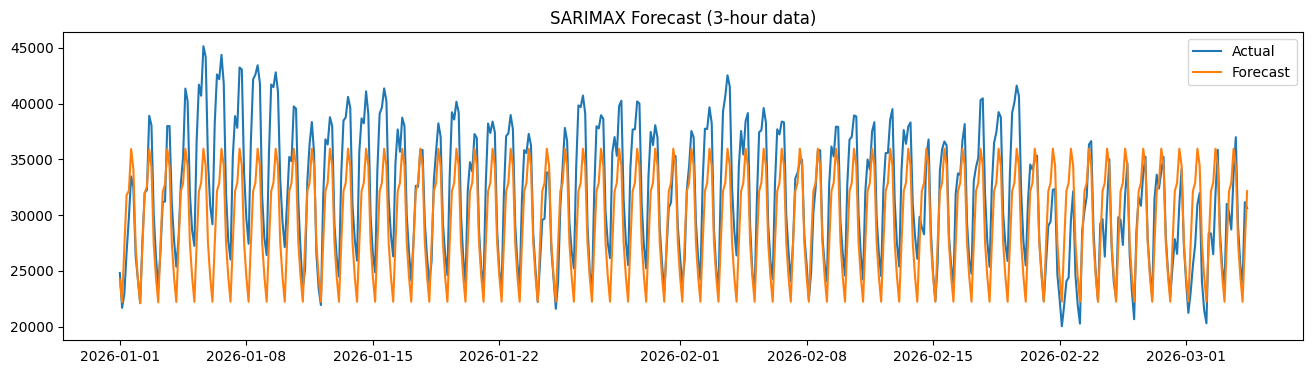

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# -------------------------------
# Ensure clean series
# -------------------------------
series = series.dropna()

# Ensure correct frequency
series = series.asfreq("3h")

# -------------------------------
# Train / Test split
# -------------------------------
train = series.loc[:'2025-12-31']
test  = series.loc['2026-01-01':]

print("Train size:", len(train))
print("Test size:", len(test))

# -------------------------------
# SARIMAX MODEL
# -------------------------------
model = SARIMAX(
    train,
    order=(2,0,2),
    seasonal_order=(1,1,1,8),  # 6 = 4-hour periods per day
    enforce_stationarity=False,
    enforce_invertibility=False
)

print("Fitting model...")
model_fit = model.fit(disp=False, maxiter=50)

# -------------------------------
# Forecast
# -------------------------------
forecast = model_fit.forecast(steps=len(test))
forecast.index = test.index

# -------------------------------
# Evaluation
# -------------------------------
mae = np.mean(np.abs(test - forecast))
rmse = np.sqrt(np.mean((test - forecast)**2))

print("SARIMAX MAE:", mae)
print("SARIMAX RMSE:", rmse)

# -------------------------------
# Plot
# -------------------------------
plt.figure(figsize=(16,4))
plt.plot(test[:500], label="Actual")
plt.plot(forecast[:500], label="Forecast")
plt.legend()
plt.title("SARIMAX Forecast (3-hour data)")
plt.show()

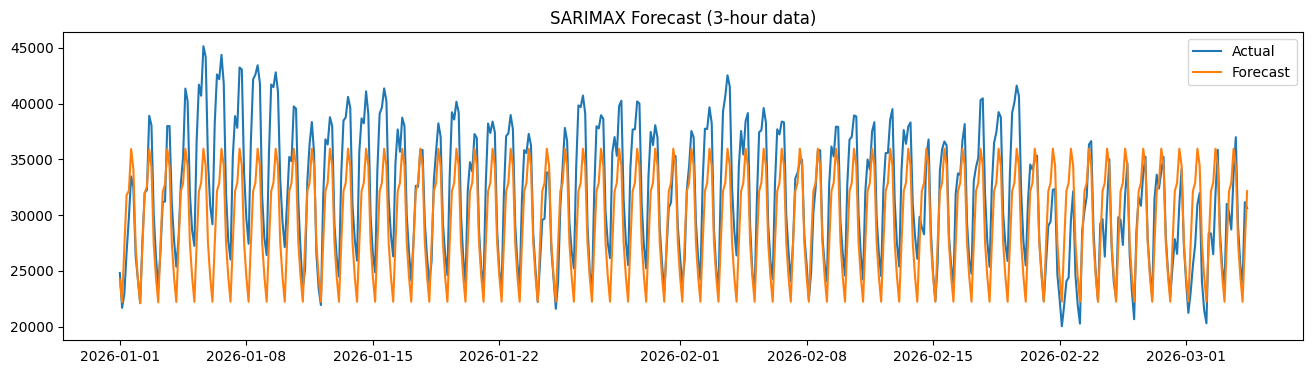

In [23]:
plt.figure(figsize=(16,4))
plt.plot(test[:500], label="Actual")
plt.plot(forecast[:500], label="Forecast")
plt.legend()
plt.title("SARIMAX Forecast (3-hour data)")
plt.show()

In [ ]:
import itertools
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX

# -------------------------------
# Parameter grid (SMALL & SAFE)
# -------------------------------
p = [0, 1, 2]
d = [0, 1]
q = [0, 1, 2]

P = [0, 1]
D = [0, 1]
Q = [0, 1]

s = 8  # 3-hour data → 8 periods per day (24 / 3 = 8)

# -------------------------------
# Store best result
# -------------------------------
best_mae = float("inf")
best_order = None
best_seasonal = None

results = []

# -------------------------------
# Grid search
# -------------------------------
for order in itertools.product(p, d, q):
    for seasonal in itertools.product(P, D, Q):
        seasonal_order = (seasonal[0], seasonal[1], seasonal[2], s)

        try:
            model = SARIMAX(
                train,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            model_fit = model.fit(disp=False, maxiter=30)

            forecast = model_fit.forecast(steps=len(test))

            mae = np.mean(np.abs(test - forecast))

            results.append((order, seasonal_order, mae))

            if mae < best_mae:
                best_mae = mae
                best_order = order
                best_seasonal = seasonal_order

            print(f"Tested {order} x {seasonal_order} → MAE: {mae:.2f}")

        except:
            continue

# -------------------------------
# BEST RESULT
# -------------------------------
print("\nBEST MODEL:")
print("Order:", best_order)
print("Seasonal:", best_seasonal)
print("Best MAE:", best_mae)

Tested (0, 0, 0) x (0, 0, 0, 8) → MAE: 30544.41
Tested (0, 0, 0) x (0, 0, 1, 8) → MAE: 30412.12
Tested (0, 0, 0) x (0, 1, 0, 8) → MAE: 3182.84
Tested (0, 0, 0) x (0, 1, 1, 8) → MAE: 3144.67
Tested (0, 0, 0) x (1, 0, 0, 8) → MAE: 5271.12
Tested (0, 0, 0) x (1, 0, 1, 8) → MAE: 4906.47
Tested (0, 0, 0) x (1, 1, 0, 8) → MAE: 3170.93
Tested (0, 0, 0) x (1, 1, 1, 8) → MAE: 3111.84
Tested (0, 0, 1) x (0, 0, 0, 8) → MAE: 30528.26
Tested (0, 0, 1) x (0, 0, 1, 8) → MAE: 30379.73
Tested (0, 0, 1) x (0, 1, 0, 8) → MAE: 3153.83
Tested (0, 0, 1) x (0, 1, 1, 8) → MAE: 3270.25
Tested (0, 0, 1) x (1, 0, 0, 8) → MAE: 6791.64


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Tested (0, 0, 1) x (1, 0, 1, 8) → MAE: 155019058557350807727266332672.00
Tested (0, 0, 1) x (1, 1, 0, 8) → MAE: 3189.01


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Tested (0, 0, 1) x (1, 1, 1, 8) → MAE: 3266.08
Tested (0, 0, 2) x (0, 0, 0, 8) → MAE: 30499.13


...

Tested (2, 1, 1) x (0, 1, 1, 8) → MAE: 3496.07


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Tested (2, 1, 1) x (1, 0, 0, 8) → MAE: 4763.23
Tested (2, 1, 1) x (1, 0, 1, 8) → MAE: 3144.08
Tested (2, 1, 1) x (1, 1, 0, 8) → MAE: 81830.38
Tested (2, 1, 1) x (1, 1, 1, 8) → MAE: 6780.87
Tested (2, 1, 2) x (0, 0, 0, 8) → MAE: 4883.02
Tested (2, 1, 2) x (0, 0, 1, 8) → MAE: 4860.88


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Tested (2, 1, 2) x (0, 1, 0, 8) → MAE: 3274.63
Tested (2, 1, 2) x (0, 1, 1, 8) → MAE: 3177.69
Tested (2, 1, 2) x (1, 0, 0, 8) → MAE: 5141.78


In [ ]:
# -------------------------------
# FUNCTION: Evaluate Horizon
# -------------------------------
def evaluate_sarimax(horizon_steps):

    preds = []
    actuals = []
    # Store corresponding timestamps
    timestamps = []

    for i in range(len(test) - horizon_steps):

        # forecast from point i
        forecast = model_fit.forecast(steps=horizon_steps)

        pred = forecast.values[-1]  # last step prediction
        actual = test.values[i + horizon_steps]
        timestamp = test.index[i + horizon_steps] # Get the timestamp for the actual value

        preds.append(pred)
        actuals.append(actual)
        timestamps.append(timestamp) # Append timestamp

    preds = np.array(preds)
    actuals = np.array(actuals)
    timestamps = pd.to_datetime(timestamps) # Convert to DatetimeIndex

    mae = np.mean(np.abs(actuals - preds))
    rmse = np.sqrt(np.mean((actuals - preds)**2))

    return mae, rmse, preds, actuals, timestamps # Return timestamps as well

# -------------------------------
# Day-ahead (6 steps)
# -------------------------------
mae_day, rmse_day, pred_day, actual_day, time_index_day = evaluate_sarimax(6)

# -------------------------------
# Week-ahead (42 steps)
# -------------------------------
mae_week, rmse_week, pred_week, actual_week, time_index_week = evaluate_sarimax(42)

print("SARIMAX Day-ahead MAE:", mae_day)
print("SARIMAX Week-ahead MAE:", mae_week)

import matplotlib.dates as mdates # Import mdates

# -------------------------------
# Plot Day-ahead Forecast
# -------------------------------
plt.figure(figsize=(16, 6))
# Plot using the actual time index
plt.plot(time_index_day, actual_day, label="Actual (Day-ahead)", color='blue')
plt.plot(time_index_day, pred_day, label="Predicted (Day-ahead)", color='red', linestyle='--')
plt.title("SARIMAX Day-ahead Forecast vs Actual")
plt.xlabel("Time") # Changed from "Time Step"
plt.ylabel("Demand (MW)")
plt.legend()
plt.grid(True)
# Format x-axis for hours
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gcf().autofmt_xdate() # Auto-format for better readability
plt.show()

# -------------------------------
# Plot Week-ahead Forecast
# -------------------------------
plt.figure(figsize=(16, 6))
# Plot using the actual time index
plt.plot(time_index_week, actual_week, label="Actual (Week-ahead)", color='blue')
plt.plot(time_index_week, pred_week, label="Predicted (Week-ahead)", color='green', linestyle='--')
plt.title("SARIMAX Week-ahead Forecast vs Actual")
plt.xlabel("Date") # Changed from "Time Step"
plt.ylabel("Demand (MW)")
plt.legend()
plt.grid(True)
# Format x-axis for dates
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gcf().autofmt_xdate() # Auto-format for better readability
plt.show()

In [11]:
# # a new sarimax
# import numpy as np
# import matplotlib.pyplot as plt
# from statsmodels.tsa.statespace.sarimax import SARIMAX

# # -------------------------------
# # Ensure clean series
# # -------------------------------
# series = series.dropna()
# series = series.asfreq("4h")

# # -------------------------------
# # Train / Test split
# # -------------------------------
# train = series.loc[:'2023']
# test  = series.loc['2024':]

# # -------------------------------
# # Fit SARIMAX
# # -------------------------------
# model = SARIMAX(
#     train,
#     order=(2,0,2),
#     seasonal_order=(1,1,1,6),  # 6 = daily seasonality (4h data)
#     enforce_stationarity=False,
#     enforce_invertibility=False
# )

# model_fit = model.fit(disp=False, maxiter=50)

# # -------------------------------
# # FUNCTION: Evaluate Horizon
# # -------------------------------
# def evaluate_sarimax(horizon_steps):

#     preds = []
#     actuals = []

#     for i in range(len(test) - horizon_steps):

#         # forecast from point i
#         forecast = model_fit.forecast(steps=horizon_steps)

#         pred = forecast.values[-1]  # last step prediction
#         actual = test.values[i + horizon_steps]

#         preds.append(pred)
#         actuals.append(actual)

#     preds = np.array(preds)
#     actuals = np.array(actuals)

#     mae = np.mean(np.abs(actuals - preds))
#     rmse = np.sqrt(np.mean((actuals - preds)**2))

#     return mae, rmse, preds, actuals

# # -------------------------------
# # Day-ahead (6 steps)
# # -------------------------------
# mae_day, rmse_day, pred_day, actual_day = evaluate_sarimax(6)

# # -------------------------------
# # Week-ahead (42 steps)
# # -------------------------------
# mae_week, rmse_week, pred_week, actual_week = evaluate_sarimax(42)

# print("SARIMAX Day-ahead MAE:", mae_day)
# print("SARIMAX Week-ahead MAE:", mae_week)

KeyboardInterrupt: 